In [2]:
# ==========================================================
# SALES FORECASTING
# Customer Intelligence Platform Version 3.0
# ==========================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date Handling
from datetime import datetime

# Machine Learning
from prophet import Prophet

# Model Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

# Save Models
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

c:\Users\Administrator\Customer Intelligence Platform\Customer-Intelligence-Platform\customer\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# ==========================================================
# Load Datasets
# ==========================================================

orders = pd.read_csv("../data/olist_orders_dataset.csv")
payments = pd.read_csv("../data/olist_order_payments_dataset.csv")

In [5]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [6]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [7]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 21.9 MB


In [8]:
payments.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 8.1 MB


In [9]:
print("Orders Shape:", orders.shape)

print("Payments Shape:", payments.shape)

Orders Shape: (99441, 8)
Payments Shape: (103886, 5)


In [10]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [11]:
payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

# Data Preparation

In [12]:
# ==========================================================
# Keep Delivered Orders
# ==========================================================

orders = orders[
    orders["order_status"] == "delivered"
]

print("Delivered Orders:", len(orders))

Delivered Orders: 96478


In [13]:
# ==========================================================
# Merge Orders with Payments
# ==========================================================

sales = pd.merge(
    orders,
    payments,
    on="order_id",
    how="inner"
)

sales.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,credit_card,3,179.12


In [14]:
# ==========================================================
# Convert Purchase Timestamp
# ==========================================================

sales["order_purchase_timestamp"] = pd.to_datetime(
    sales["order_purchase_timestamp"]
)

sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 100756 entries, 0 to 100755
Data columns (total 12 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       100756 non-null  str           
 1   customer_id                    100756 non-null  str           
 2   order_status                   100756 non-null  str           
 3   order_purchase_timestamp       100756 non-null  datetime64[us]
 4   order_approved_at              100742 non-null  str           
 5   order_delivered_carrier_date   100754 non-null  str           
 6   order_delivered_customer_date  100748 non-null  str           
 7   order_estimated_delivery_date  100756 non-null  str           
 8   payment_sequential             100756 non-null  int64         
 9   payment_type                   100756 non-null  str           
 10  payment_installments           100756 non-null  int64         
 11  payment_val

In [15]:
sales = sales[
    [
        "order_purchase_timestamp",
        "payment_value"
    ]
]

sales.head()

,order_purchase_timestamp,payment_value
0,2017-10-02 10:56:33,18.12
1,2017-10-02 10:56:33,2.00
2,2017-10-02 10:56:33,18.59
3,2018-07-24 20:41:37,141.46
4,2018-08-08 08:38:49,179.12


In [16]:
# ==========================================================
# Daily Sales
# ==========================================================

daily_sales = (
    sales
    .groupby(
        sales["order_purchase_timestamp"].dt.date
    )["payment_value"]
    .sum()
    .reset_index()
)

daily_sales.columns = [
    "date",
    "sales"
]

daily_sales.head()

,date,sales
0,2016-10-03,559.53
1,2016-10-04,9821.42
2,2016-10-05,7209.50
3,2016-10-06,6733.52
4,2016-10-07,6832.76


In [17]:
print(daily_sales.shape)

daily_sales.describe()

(611, 2)


,sales
count,611.000000
mean,25241.344959
std,14348.063127
min,19.620000
25%,14871.165000
50%,23280.780000
75%,33648.810000
max,175250.940000


In [18]:
daily_sales.head()

daily_sales.tail()

,date,sales
606,2018-08-25,11737.76
607,2018-08-26,9304.00
608,2018-08-27,6111.60
609,2018-08-28,4121.23
610,2018-08-29,1762.70


# Exploratory Data Analysis

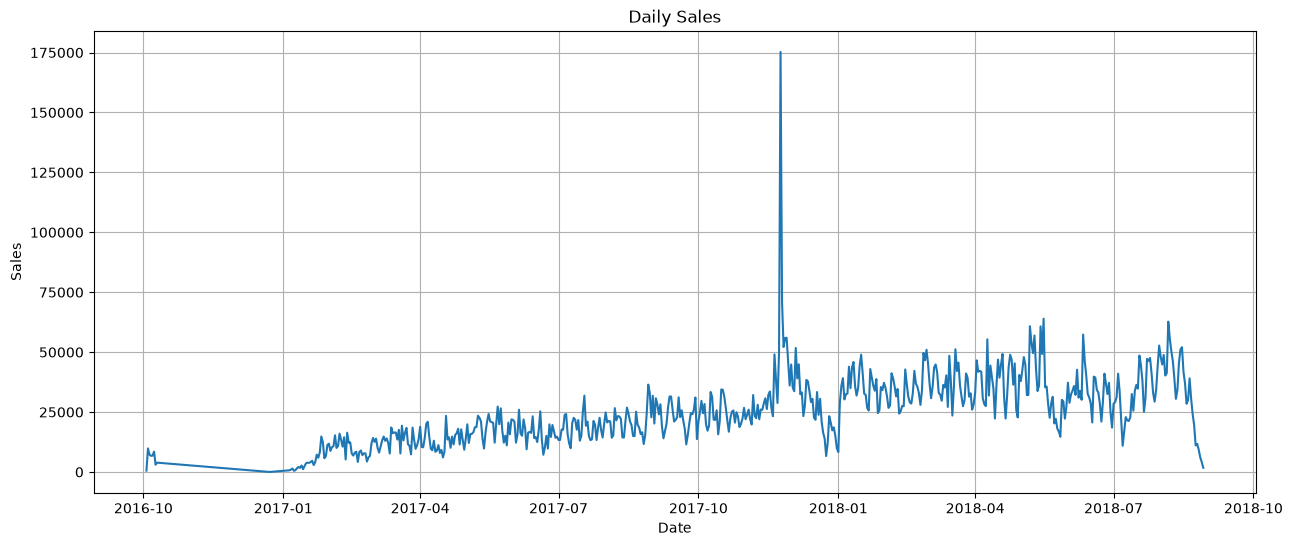

In [19]:
# ==========================================================
# Daily Sales Trend
# ==========================================================

plt.figure(figsize=(15,6))

plt.plot(
    daily_sales["date"],
    daily_sales["sales"]
)

plt.title("Daily Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [21]:
daily_sales["date"] = pd.to_datetime(
    daily_sales["date"]
)
daily_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 611 entries, 0 to 610
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   date    611 non-null    datetime64[s]
 1   sales   611 non-null    float64      
dtypes: datetime64[s](1), float64(1)
memory usage: 9.7 KB


In [23]:
monthly_sales = (
    daily_sales
    .set_index("date")
    .resample("ME")
    .sum()
)

monthly_sales.head()

,sales
date,
2016-10-31,46566.71
2016-11-30,0.00
2016-12-31,19.62
2017-01-31,127545.67
2017-02-28,271298.65


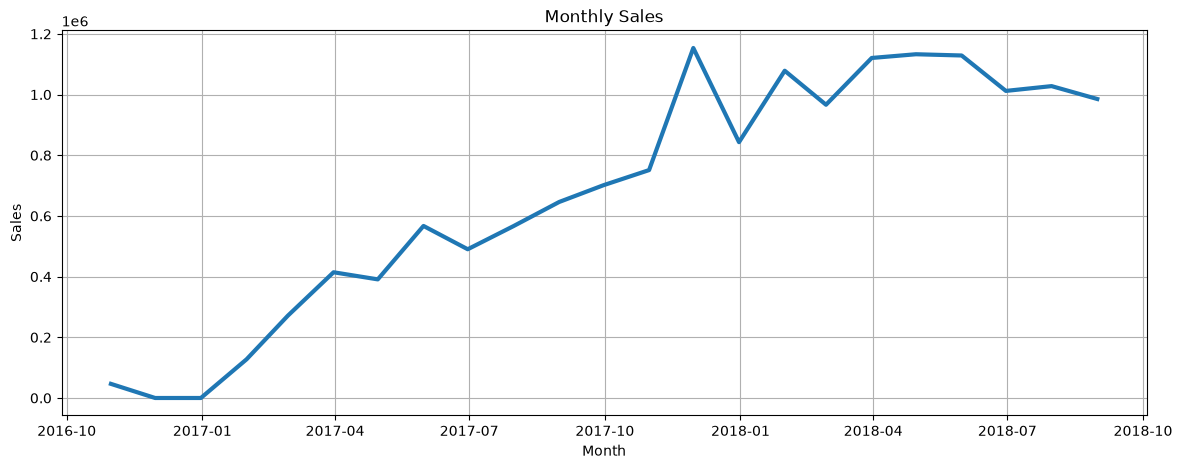

In [24]:
plt.figure(figsize=(14,5))

plt.plot(
    monthly_sales.index,
    monthly_sales["sales"],
    linewidth=3
)

plt.title("Monthly Sales")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [25]:
daily_sales["30_day_MA"] = (
    daily_sales["sales"]
    .rolling(30)
    .mean()
)

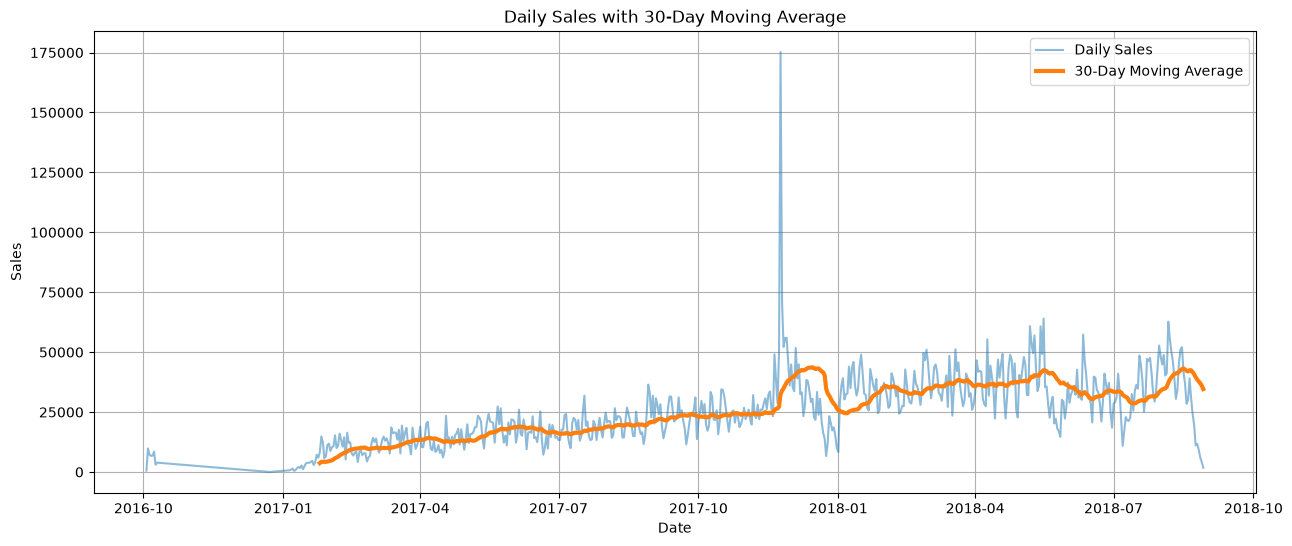

In [26]:
plt.figure(figsize=(15,6))

plt.plot(
    daily_sales["date"],
    daily_sales["sales"],
    alpha=0.5,
    label="Daily Sales"
)

plt.plot(
    daily_sales["date"],
    daily_sales["30_day_MA"],
    linewidth=3,
    label="30-Day Moving Average"
)

plt.legend()

plt.title("Daily Sales with 30-Day Moving Average")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [27]:
print("Minimum Sales :", daily_sales["sales"].min())

print("Maximum Sales :", daily_sales["sales"].max())

print("Average Sales :", daily_sales["sales"].mean())

print("Median Sales :", daily_sales["sales"].median())

print("Standard Deviation :", daily_sales["sales"].std())

Minimum Sales : 19.62
Maximum Sales : 175250.94
Average Sales : 25241.344959083468
Median Sales : 23280.78
Standard Deviation : 14348.063126995596


In [28]:
date_range = pd.date_range(
    start=daily_sales["date"].min(),
    end=daily_sales["date"].max()
)

print("Expected Days :", len(date_range))

print("Actual Days :", len(daily_sales))

print("Missing Days :", len(date_range) - len(daily_sales))

Expected Days : 696
Actual Days : 611
Missing Days : 85


In [29]:
# ==========================================================
# Fill Missing Dates
# ==========================================================

daily_sales = daily_sales.set_index("date")

daily_sales = daily_sales.asfreq("D")

daily_sales["sales"] = daily_sales["sales"].fillna(0)

daily_sales = daily_sales.reset_index()

daily_sales.head()

,date,sales,30_day_MA
0,2016-10-03,559.53,NaN
1,2016-10-04,9821.42,NaN
2,2016-10-05,7209.50,NaN
3,2016-10-06,6733.52,NaN
4,2016-10-07,6832.76,NaN


In [30]:
print("Rows:", len(daily_sales))

print("Missing Sales:", daily_sales["sales"].isnull().sum())

print("Missing Dates:", daily_sales["date"].isnull().sum())

Rows: 696
Missing Sales: 0
Missing Dates: 0


# Prepare Data for Forecasting

In [51]:
# ==========================================================
# Prepare Dataset for Prophet
# ==========================================================

forecast_data = daily_sales[
    [
        "date",
        "sales"
    ]
].copy()

In [52]:
forecast_data.columns = [
    "ds",
    "y"
]

In [53]:
forecast_data.head()

,ds,y
0,2016-10-03,559.53
1,2016-10-04,9821.42
2,2016-10-05,7209.50
3,2016-10-06,6733.52
4,2016-10-07,6832.76


In [54]:
forecast_data.isnull().sum()

ds    0
y     0
dtype: int64

In [55]:
forecast_data = forecast_data[
    forecast_data["ds"] < "2018-08-20"
]

In [56]:
# ==========================================================
# Train-Test Split
# ==========================================================

train = forecast_data.iloc[:-30]

test = forecast_data.iloc[-30:]

In [57]:
print("Training Records :", len(train))

print("Testing Records :", len(test))

Training Records : 656
Testing Records : 30


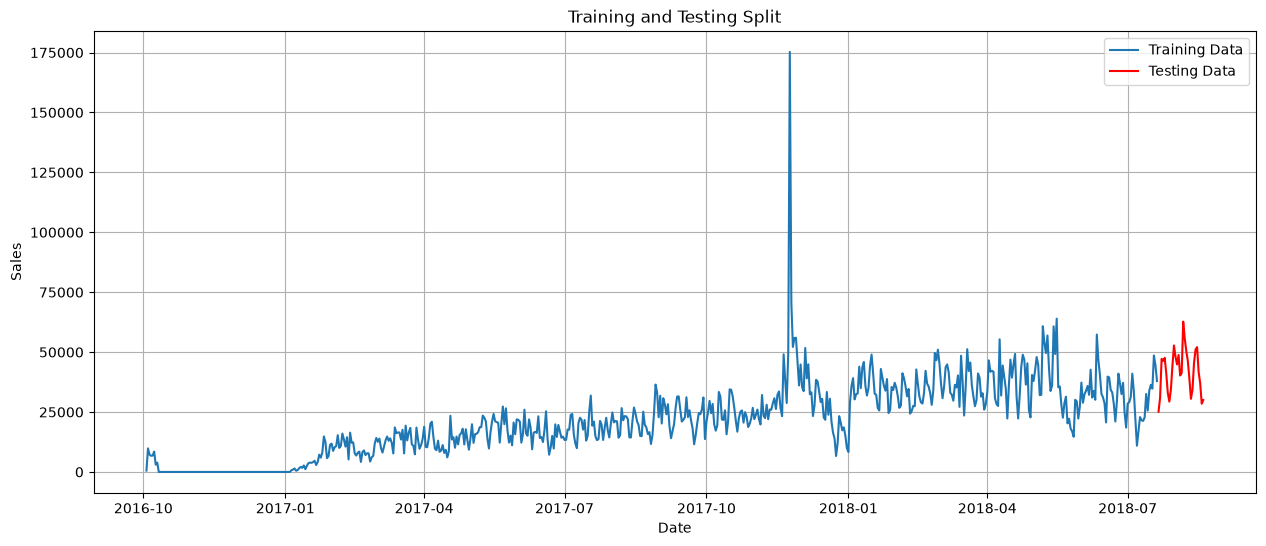

In [58]:
plt.figure(figsize=(15,6))

plt.plot(
    train["ds"],
    train["y"],
    label="Training Data"
)

plt.plot(
    test["ds"],
    test["y"],
    label="Testing Data",
    color="red"
)

plt.title("Training and Testing Split")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

# Train the Sales Forecasting Model

In [59]:
# ==========================================================
# Create Prophet Model
# ==========================================================

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

In [60]:
# ==========================================================
# Train Model
# ==========================================================

model.fit(train)

14:06:47 - cmdstanpy - INFO - Chain [1] start processing
14:06:49 - cmdstanpy - INFO - Chain [1] done processing


In [61]:
# ==========================================================
# Predict Test Data
# ==========================================================

forecast = model.predict(test)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2018-07-21,35357.030800,20453.819507,40176.546924,35357.030800,35357.030800,-5384.496652,-5384.496652,-5384.496652,-4786.801850,-4786.801850,-4786.801850,-597.694802,-597.694802,-597.694802,0.0,0.0,0.0,29972.534147
1,2018-07-22,35368.592025,21446.036047,40775.247598,35368.592025,35368.592025,-4152.354272,-4152.354272,-4152.354272,-3902.223761,-3902.223761,-3902.223761,-250.130510,-250.130510,-250.130510,0.0,0.0,0.0,31216.237754
2,2018-07-23,35380.153251,28081.371775,48886.304584,35380.153251,35380.153251,3162.381270,3162.381270,3162.381270,3119.228913,3119.228913,3119.228913,43.152356,43.152356,43.152356,0.0,0.0,0.0,38542.534521
3,2018-07-24,35391.714477,27333.575399,48146.318187,35391.714477,35391.714477,2775.531763,2775.531763,2775.531763,2499.443988,2499.443988,2499.443988,276.087775,276.087775,276.087775,0.0,0.0,0.0,38167.246240
4,2018-07-25,35403.275703,26806.298352,47326.862969,35403.275703,35403.275703,2237.505554,2237.505554,2237.505554,1793.416661,1793.416661,1793.416661,444.088893,444.088893,444.088893,0.0,0.0,0.0,37640.781257


In [62]:
forecast = forecast[
    [
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
]

forecast.head()

,ds,yhat,yhat_lower,yhat_upper
0,2018-07-21,29972.534147,20453.819507,40176.546924
1,2018-07-22,31216.237754,21446.036047,40775.247598
2,2018-07-23,38542.534521,28081.371775,48886.304584
3,2018-07-24,38167.246240,27333.575399,48146.318187
4,2018-07-25,37640.781257,26806.298352,47326.862969


In [63]:
results = test.merge(
    forecast,
    on="ds"
)

results.head()

,ds,y,yhat,yhat_lower,yhat_upper
0,2018-07-21,25130.58,29972.534147,20453.819507,40176.546924
1,2018-07-22,30939.74,31216.237754,21446.036047,40775.247598
2,2018-07-23,47195.40,38542.534521,28081.371775,48886.304584
3,2018-07-24,46345.99,38167.246240,27333.575399,48146.318187
4,2018-07-25,47599.78,37640.781257,26806.298352,47326.862969


In [64]:
mae = mean_absolute_error(
    results["y"],
    results["yhat"]
)

print("MAE:", mae)

MAE: 9223.760744290275


In [65]:
rmse = np.sqrt(
    mean_squared_error(
        results["y"],
        results["yhat"]
    )
)

print("RMSE:", rmse)

RMSE: 11093.615624390399


In [66]:
mape = (
    np.mean(
        np.abs(
            (results["y"] - results["yhat"]) / results["y"]
        )
    ) * 100
)

print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Percentage Error (MAPE): 20.13%


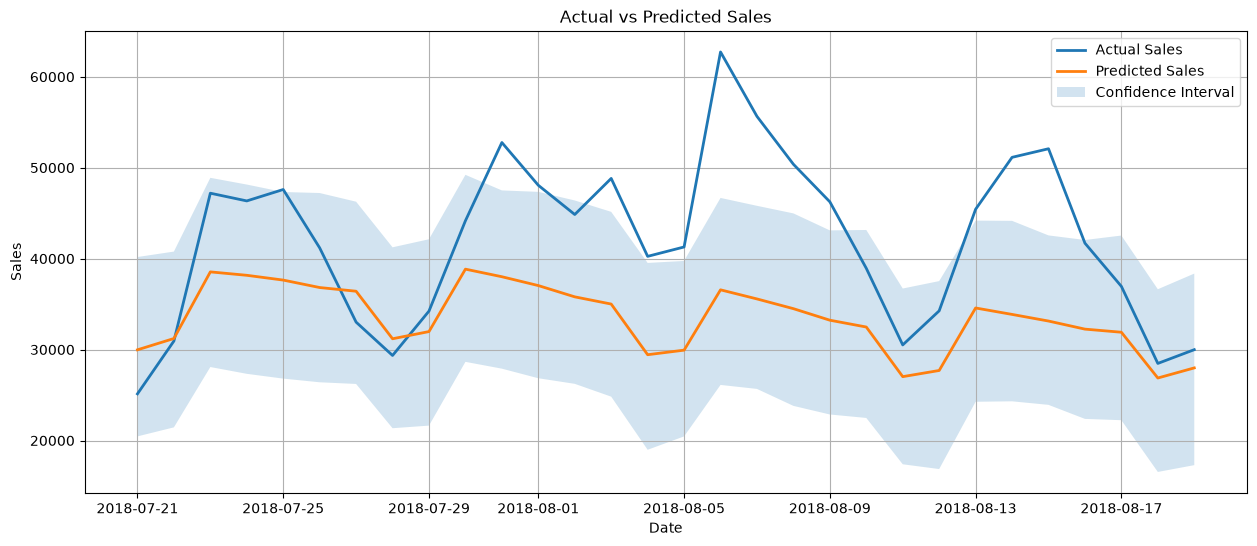

In [67]:
plt.figure(figsize=(15,6))

plt.plot(
    results["ds"],
    results["y"],
    label="Actual Sales",
    linewidth=2
)

plt.plot(
    results["ds"],
    results["yhat"],
    label="Predicted Sales",
    linewidth=2
)

plt.fill_between(
    results["ds"],
    results["yhat_lower"],
    results["yhat_upper"],
    alpha=0.2,
    label="Confidence Interval"
)

plt.title("Actual vs Predicted Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [68]:
forecast_data.tail(40)

,ds,y
646,2018-07-11,21286.74
647,2018-07-12,22767.58
648,2018-07-13,32529.39
649,2018-07-14,25593.41
650,2018-07-15,33876.60
651,2018-07-16,36329.50
652,2018-07-17,34775.60
653,2018-07-18,48588.05
654,2018-07-19,44557.39
655,2018-07-20,37905.62


In [69]:
daily_sales.tail(40)

,date,sales,30_day_MA
656,2018-07-21,25130.58,29699.867000
657,2018-07-22,30939.74,29781.706000
658,2018-07-23,47195.40,30653.431000
659,2018-07-24,46345.99,31221.911000
660,2018-07-25,47599.78,31441.093333
661,2018-07-26,41183.98,31580.575333
662,2018-07-27,33017.33,31597.622000
663,2018-07-28,29350.49,31336.539333
664,2018-07-29,34233.31,31649.072667
665,2018-07-30,44165.92,32504.519667


In [70]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders.groupby(
    orders["order_purchase_timestamp"].dt.date
).size().tail(15)

order_purchase_timestamp
2018-08-15    282
2018-08-16    316
2018-08-17    249
2018-08-18    193
2018-08-19    204
2018-08-20    251
2018-08-21    238
2018-08-22    185
2018-08-23    142
2018-08-24     96
2018-08-25     69
2018-08-26     73
2018-08-27     66
2018-08-28     39
2018-08-29     11
dtype: int64